## Business Understanding

### Overview

##### During the 2009 H1N1 influenza pandemic, public health organizations faced the challenge of ensuring that as many people as possible received the H1N1 vaccine. However, not everyone chose to get vaccinated due to differences in health beliefs, demographic factors and access to healthcare. Understanding which groups are more likely or less likely to receive the vaccine can help public health agencies design better vaccination campaigns and allocate resources more effectively.

##### The goal of this project is to develop a machine learning model that predicts whether an individual is likely to receive the H1N1 flu vaccine based on demographic characteristics, health behaviors and opinions about vaccines. By analyzing these factors, the model can identify patterns that influence vaccination decisions.

##### This analysis can provide valuable insights for healthcare organizations, policymakers and public health officials. With accurate predictions, targeted awareness campaigns can be directed toward groups that are less likely to get vaccinated. This can improve vaccination rates, reduce the spread of infectious diseases and ultimately protect public health.

##### In addition, improving vaccine uptake helps reduce healthcare costs, hospitalizations and the burden on healthcare systems during outbreaks. Therefore, the development of predictive models has important real-world implications for disease prevention and health policy planning.

### Business Problem

##### Despite the availability of vaccines during the H1N1 outbreak, many individuals did not receive them due to factors such as lack of awareness, vaccine hesitancy, or limited access to healthcare services. Public health agencies often struggle to identify which populations are less likely to get vaccinated and therefore require targeted interventions.

##### Because of this:
- Public health organisations cannot easily identify groups with low vaccination uptake.
- Vaccination campaigns may not effectivley reach the hesitant populations.
- Healthcare resources may not be allocated effeciently during outbreaks.
- Misconceptions about vaccine safety and effectiveness may continue to influence people's decisions.

### Objective

- Build a classification model to predict whether an individual received the H1N1 vaccine.

- Evaluate model performance using metrics such as accuracy, precision, recall, F1-score and ROC-AUC.

- Identify the most important factors influencing vaccination decisions.

- Provide insights that can help public health organizations design more effective vaccination campaigns.

- Support policymakers and healthcare providers in improving vaccination coverage and preventing the spread of infectious diseases.

### Business Questions

- Can we accurately predict whether an individual will receive the H1N1 vaccine using demographic, behavioral, and opinion data?
- Which demographic and health-related factors most strongly influence whether an individual receives the H1N1 vaccine?
- How do people's perceptions about vaccine safety, effectiveness, and personal risk affect their likelihood of getting vaccinated?
- How well do different machine learning models perform in predicting vaccination uptake based on survey data?
- What insights from the model can help policymakers and healthcare providers improve vaccination campaigns and increase vaccine uptake?


#### Importing Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy import stats
from scipy.stats import zscore

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import GridSearchCV



### Data Understanding

#### Loading and merging the data

In [53]:
df = pd.read_csv('H1N1_Flu_Vaccines.csv')
df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [54]:
df.shape

(26707, 38)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

##### Summary statistics

In [56]:
df.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,...,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,...,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,...,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,...,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,...,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000


Visualization to check those who received the vaccine and those who did not.

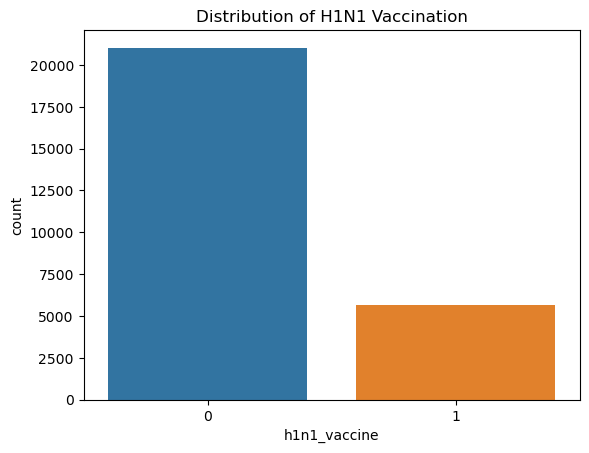

In [57]:
sns.countplot(x="h1n1_vaccine", data=df)
plt.title("Distribution of H1N1 Vaccination")
plt.show()


Our data is highly imbalanced

##### Visualizing doctor's recommendation and Vaccination

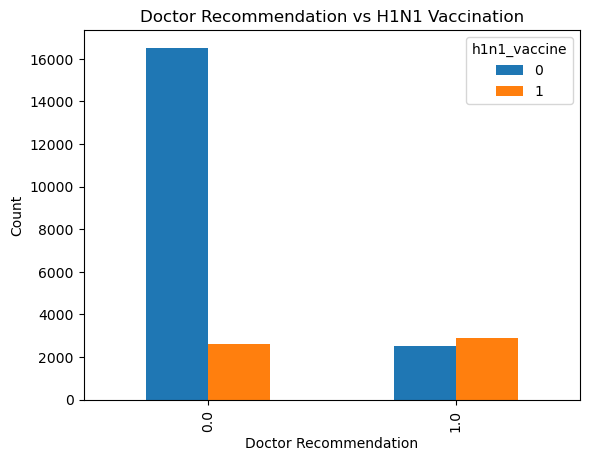

In [58]:
pd.crosstab(df["doctor_recc_h1n1"], df["h1n1_vaccine"]).plot(kind="bar")

plt.title("Doctor Recommendation vs H1N1 Vaccination")
plt.xlabel("Doctor Recommendation")
plt.ylabel("Count")

plt.show()


#### Age group vs vaccination

##### Understanding these patterns helps in identifying the demographic groups that require vaccination campaigns

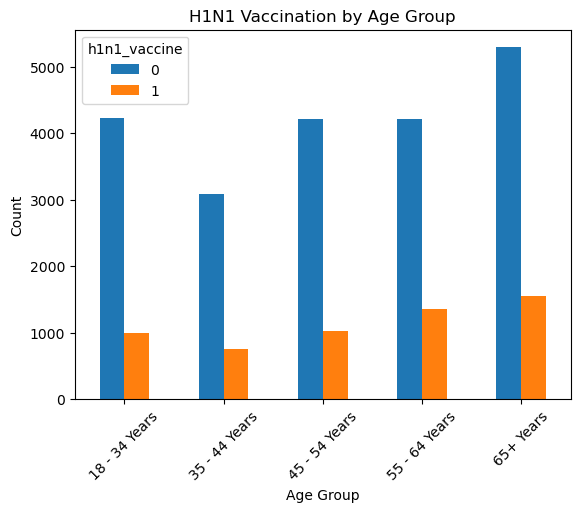

In [59]:
pd.crosstab(df["age_group"], df["h1n1_vaccine"]).plot(kind="bar")

plt.title("H1N1 Vaccination by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


#### Concern about vaccination

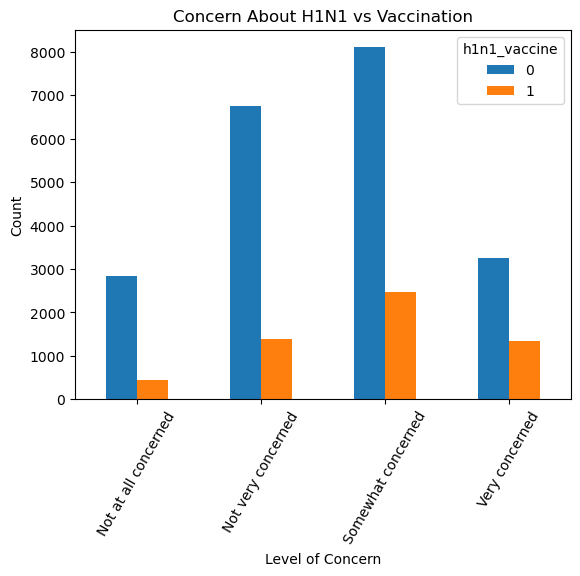

In [60]:
concern_labels = {
0: "Not at all concerned",
1: "Not very concerned",
2: "Somewhat concerned",
3: "Very concerned"
}

pd.crosstab(df["h1n1_concern"].map(concern_labels), df["h1n1_vaccine"]).plot(kind="bar")

plt.title("Concern About H1N1 vs Vaccination")
plt.xlabel("Level of Concern")
plt.ylabel("Count")

plt.xticks(rotation=60)

plt.show()


##### Defining the Target Variable and Feature Variables

The dataset is divided into two main components: the **target variable (y)** the variable we want to predict and the **feature variables (X)** which are all the variables that are to be used for prediction.

The **target variable** represents the outcome that the model is trying to predict. In this project, the target variable is h1n1_vaccine, which indicates whether an individual received the H1N1 vaccine (1 = Yes, 0 = No).




In [61]:
# Target variable
y = df["h1n1_vaccine"]

# Feature variables
X = df.drop(["h1n1_vaccine", "seasonal_vaccine", "respondent_id"], axis=1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (26707, 35)
Target shape: (26707,)


### Train-Test Split

##### Before performing any preprocessing steps such as handling missing values or encoding categorical variables, the dataset is split into training and testing sets(80/20 split).

##### This step helps to evaluate how well the model performs on unseen data and prevent data leakage, ensuring that information from the test set does not influence the training process.


In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (21365, 35)
Testing set shape: (5342, 35)


### Data Cleaning

#### Handling Missing values - Checking missing values on both training and testing data.

In [63]:
X_train.isnull().sum()

h1n1_concern                      76
h1n1_knowledge                    90
behavioral_antiviral_meds         55
behavioral_avoidance             162
behavioral_face_mask              12
behavioral_wash_hands             37
behavioral_large_gatherings       76
behavioral_outside_home           63
behavioral_touch_face            107
doctor_recc_h1n1                1731
doctor_recc_seasonal            1731
chronic_med_condition            799
child_under_6_months             676
health_worker                    662
health_insurance                9849
opinion_h1n1_vacc_effective      326
opinion_h1n1_risk                324
opinion_h1n1_sick_from_vacc      331
opinion_seas_vacc_effective      387
opinion_seas_risk                421
opinion_seas_sick_from_vacc      446
age_group                          0
education                       1143
race                               0
sex                                0
income_poverty                  3541
marital_status                  1135
r

In [64]:
X_test.isnull().sum()

h1n1_concern                     16
h1n1_knowledge                   26
behavioral_antiviral_meds        16
behavioral_avoidance             46
behavioral_face_mask              7
behavioral_wash_hands             5
behavioral_large_gatherings      11
behavioral_outside_home          19
behavioral_touch_face            21
doctor_recc_h1n1                429
doctor_recc_seasonal            429
chronic_med_condition           172
child_under_6_months            144
health_worker                   142
health_insurance               2425
opinion_h1n1_vacc_effective      65
opinion_h1n1_risk                64
opinion_h1n1_sick_from_vacc      64
opinion_seas_vacc_effective      75
opinion_seas_risk                93
opinion_seas_sick_from_vacc      91
age_group                         0
education                       264
race                              0
sex                               0
income_poverty                  882
marital_status                  273
rent_or_own                 

##### Filling missing values

In [65]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

In [66]:
# numerical columns
for col in num_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)


In [67]:
# categorical columns
for col in cat_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

##### Checking if the missing values have been handled

In [68]:
X_train.isnull().sum().sum()

0

In [69]:
X_test.isnull().sum().sum()

0

#### Encoding Categorical Variables
- Categorical features in the dataset must be converted into numerical representations. One-Hot Encoding is used to transform categorical variables into binary indicator variables. Each category is converted into a new column containing values of 0 or 1.
 - To avoid the dummy variable trap(multicollinearity), the parameter drop_first=True is applied so that one category from each feature is removed.


In [70]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)

X_test_encoded = pd.get_dummies(X_test, drop_first=True)

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)


### Data Scaling and Preprocessing

 We scale numerical features to ensure that all variables are on a similar scale, which helps improve model performance.


In [71]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)


In [72]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

Because the dataset showed class imbalance (many more people did not take the vaccine than those who did), SMOTE is applied to balance the training data. This helps the model better learn patterns from the minority class and improves recall and F1-score.

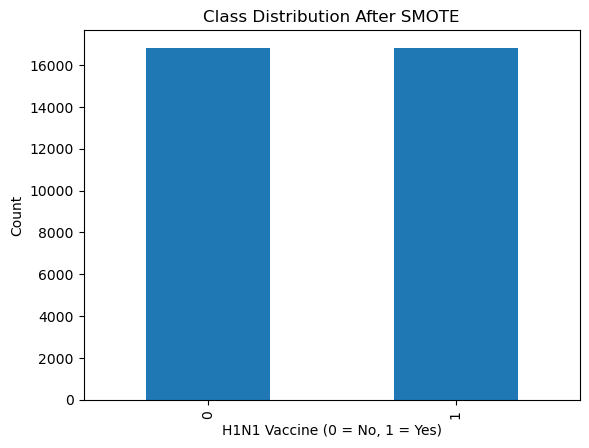

In [73]:
y_train_smote.value_counts().plot(kind='bar')

plt.title("Class Distribution After SMOTE")
plt.xlabel("H1N1 Vaccine (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

### Training Models
 - We train multiple classification models to compare their performance and identify the best model for predicting H1N1 vaccination.
 - Adding a reusable evaluation function


In [74]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    if y_prob is not None:
        print("ROC AUC:", roc_auc_score(y_test, y_prob))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

- Ridge Logistic Regression applies L2 regularization, which helps prevent overfitting by penalizing large coefficients.

In [75]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l2", solver="liblinear", max_iter=1000, random_state=42))
])

ridge_pipeline.fit(X_train_smote, y_train_smote)

y_pred_ridge = ridge_pipeline.predict(X_test_scaled)
y_prob_ridge = ridge_pipeline.predict_proba(X_test_scaled)[:,1]

evaluate_model(ridge_pipeline, X_test_scaled, y_test)



Accuracy: 0.7766754024709847
Precision: 0.48302107728337235
Recall: 0.7268722466960352
F1 Score: 0.5803728455856489
ROC AUC: 0.8262608260409282

Confusion Matrix:
[[3324  883]
 [ 310  825]]


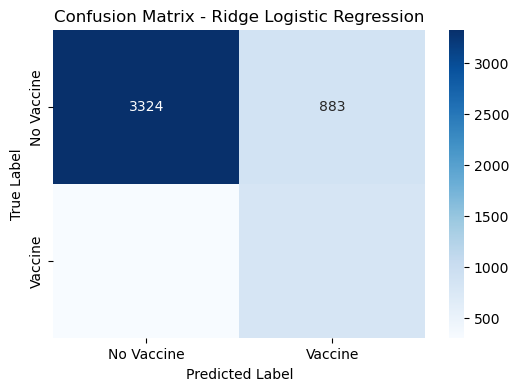

In [76]:
# Confusion matrix for Ridge Logistic Regression
cm = confusion_matrix(y_test, y_pred_ridge)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Vaccine', 'Vaccine'],
            yticklabels=['No Vaccine', 'Vaccine'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Ridge Logistic Regression")

plt.show()

 The Ridge Logistic Regression model achieved an accuracy of 77.7% and an ROC-AUC score of 0.826, indicating good ability to distinguish between vaccinated and non-vaccinated individuals. The model achieved relatively high recall (72.7%), meaning it successfully identified most individuals who received the vaccine. However, precision was lower (48.3%), suggesting that some individuals predicted as vaccinated were actually not vaccinated.

#### Lasso Logistic Regression
- Lasso Logistic Regression uses L1 regularization which shrinks some coefficients to zero, perfoming feature selection.

In [77]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000, random_state=42))
])

lasso_pipeline.fit(X_train_smote, y_train_smote)

y_pred_lasso = lasso_pipeline.predict(X_test_scaled)
y_prob_lasso = lasso_pipeline.predict_proba(X_test_scaled)[:,1]

evaluate_model(lasso_pipeline, X_test_scaled, y_test)


Accuracy: 0.7768625982777986
Precision: 0.4833040421792619
Recall: 0.7268722466960352
F1 Score: 0.5805770584095707
ROC AUC: 0.8262392551118389

Confusion Matrix:
[[3325  882]
 [ 310  825]]


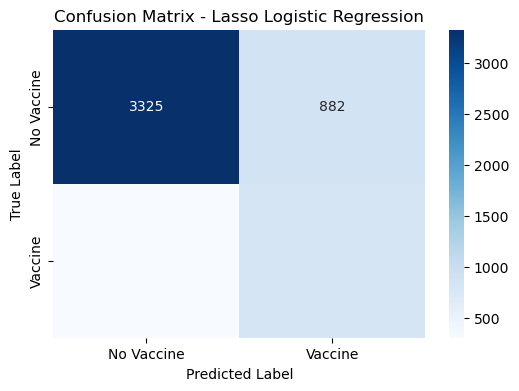

In [78]:
cm = confusion_matrix(y_test, y_pred_lasso)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Vaccine', 'Vaccine'],
            yticklabels=['No Vaccine', 'Vaccine'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Lasso Logistic Regression")

plt.show()

The Lasso Logistic Regression model achieved an accuracy of **77.7%**, indicating that most predictions were correct. The model achieved a **recall of 72.7%**, meaning it successfully identified a large proportion of individuals who received the H1N1 vaccine.However, the model's **precision was 48.3%**, indicating that some individuals predicted as vaccinated were actually not vaccinated. This suggests the model produces a moderate number of false positives. The **F1 score of 0.58** reflects the balance between precision and recall, while the **ROC-AUC score of 0.826** indicates that the model has strong ability to distinguish between vaccinated and non-vaccinated individuals.


The Logistic Regression model provides a baseline for comparison. It performs reasonably well but may struggle to capture complex relationships in the data.


Random Forest Training 

In [79]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]
evaluate_model(rf_model, X_test_scaled, y_test)


Accuracy: 0.8382628229127668
Precision: 0.6843537414965987
Recall: 0.4431718061674009
F1 Score: 0.5379679144385027
ROC AUC: 0.8219629754897699

Confusion Matrix:
[[3975  232]
 [ 632  503]]


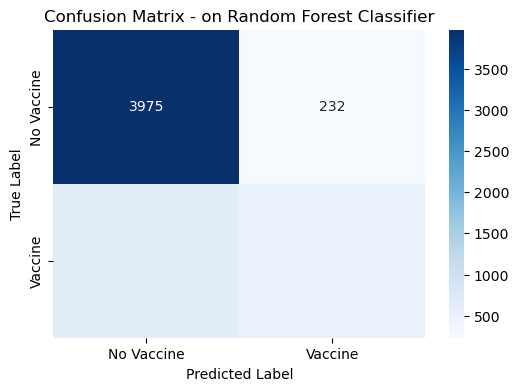

In [80]:
cm = confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Vaccine', 'Vaccine'],
            yticklabels=['No Vaccine', 'Vaccine'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - on Random Forest Classifier")

plt.show()

The Random Forest model improves performance by combining multiple trees, reducing overfitting and increasing accuracy.


Using GradientBoosting to improve f1 score.

In [81]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_smote, y_train_smote)


GradientBoostingClassifier(random_state=42)

In [82]:
y_pred_gb = gb_model.predict(X_test_scaled)

y_prob_gb = gb_model.predict_proba(X_test_scaled)[:,1]
evaluate_model(gb_model, X_test_scaled, y_test)


Accuracy: 0.8362036690378135
Precision: 0.6508120649651972
Recall: 0.49427312775330395
F1 Score: 0.5618427641462194
ROC AUC: 0.8284474480857894

Confusion Matrix:
[[3906  301]
 [ 574  561]]


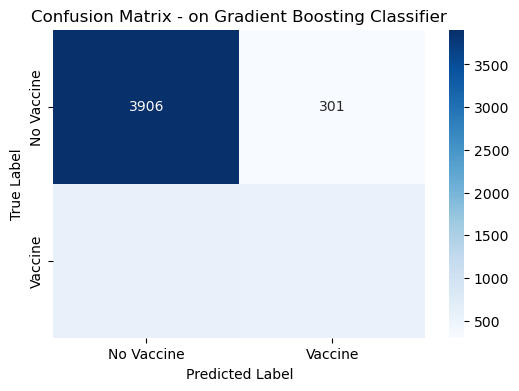

In [83]:
cm = confusion_matrix(y_test, y_pred_gb)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Vaccine', 'Vaccine'],
            yticklabels=['No Vaccine', 'Vaccine'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - on Gradient Boosting Classifier")

plt.show()

The Gradient Boosting model achieves the best performance, indicating its ability to capture complex patterns and interactions in the data.

It improved the models ability to correctly identify individuals likely to take h1n1 vaccine resulting in a more balanced model performance. It is preferred because it achieves the best balance between recall and precision.

#### Feature Importance
- Feature importance helps identify which variables contribute the most to the model’s predictions.

In [84]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_encoded.columns
)

importance.sort_values(ascending=False).head(10)


opinion_h1n1_vacc_effective    0.099990
doctor_recc_h1n1               0.096685
opinion_h1n1_risk              0.088284
opinion_seas_risk              0.072204
opinion_seas_vacc_effective    0.050673
h1n1_knowledge                 0.037637
doctor_recc_seasonal           0.037070
h1n1_concern                   0.033082
opinion_h1n1_sick_from_vacc    0.030419
opinion_seas_sick_from_vacc    0.025051
dtype: float64

Visualizing feature importance

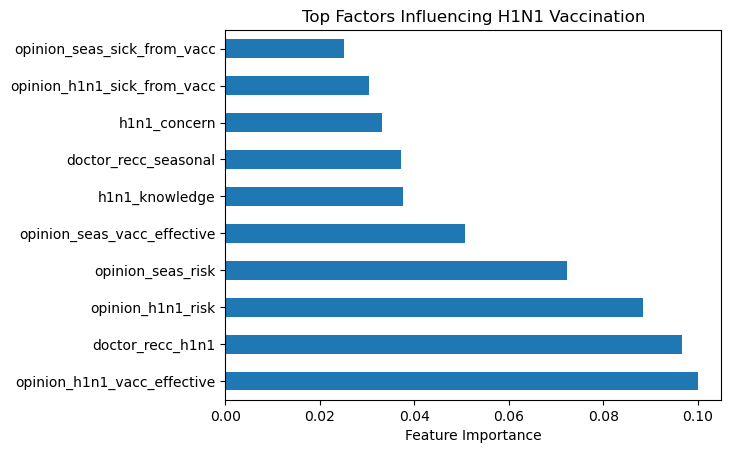

In [85]:
importance.sort_values(ascending=False).head(10).plot(kind="barh")

plt.title("Top Factors Influencing H1N1 Vaccination")

plt.xlabel("Feature Importance")

plt.show()


#### ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) curve is used to evaluate the classification performance of the models. It shows the trade-off between the true positive rate (recall) and the false positive rate.

The Area Under the Curve (AUC) provides a single value summarizing the model's ability to distinguish between the two classes. A higher AUC value indicates better model performance.

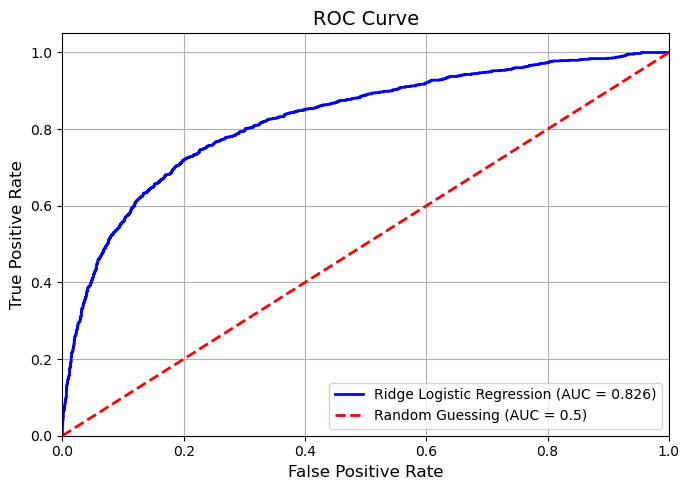

In [86]:
# Function to safely get probabilities for positive class
def get_positive_probs(preds):
    preds = np.array(preds)
    # If 2D, assume columns = [prob_class0, prob_class1]
    if preds.ndim == 2:
        return preds[:,1]
    # If 1D, assume predicted labels; use as-is (less precise for ROC)
    elif preds.ndim == 1:
        return preds
    else:
        raise ValueError("Unexpected shape for predictions")

# Get probabilities for Ridge Logistic Regression
y_probs_ridge = get_positive_probs(y_prob_ridge)

# Compute ROC
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_probs_ridge)
roc_auc_ridge = auc(fpr_ridge, tpr_ridge)

# Plot ROC curve
plt.figure(figsize=(7,5))
plt.plot(fpr_ridge, tpr_ridge, color='blue', lw=2,
         label='Ridge Logistic Regression (AUC = %.3f)' % roc_auc_ridge)

# Random guessing line
plt.plot([0,1], [0,1], color='red', linestyle='--', lw=2, label='Random Guessing (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


The Ridge Logistic Regression model achieved an AUC score of approximately 0.826, indicating good classification performance. An AUC above 0.8 suggests that the model has a strong ability to correctly differentiate between the two classes.

### Model Comparison 

In [87]:
model_results = pd.DataFrame({
    "Model": ["Ridge Logistic Regression",
              "Lasso Logistic Regression",
              "Random Forest",
              "Gradient Boosting"],

    "Accuracy": [0.7767, 0.7769, 0.8383, 0.8362],
    "Precision": [0.4830, 0.4833, 0.6844, 0.6508],
    "Recall": [0.7269, 0.7269, 0.4432, 0.4943],
    "F1 Score": [0.5804, 0.5806, 0.5380, 0.5618],
    "ROC AUC": [0.8263, 0.8262, 0.8220, 0.8284]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Ridge Logistic Regression,0.7767,0.4830,0.7269,0.5804,0.8263
1,Lasso Logistic Regression,0.7769,0.4833,0.7269,0.5806,0.8262
2,Random Forest,0.8383,0.6844,0.4432,0.5380,0.8220
3,Gradient Boosting,0.8362,0.6508,0.4943,0.5618,0.8284


### Model Performance Summary

Among all models tested, Gradient Boosting performed best based on evaluation metrics such as accuracy and ROC-AUC.

This suggests it is the most suitable model for predicting H1N1 vaccination behavior.


### Conclusion

The objective of this project was to build a classification model that can predict whether an individual received the H1N1 vaccine using demographic, behavioral and opinion-based survey data. Multiple machine learning models were trained and evaluated using performance metrics such as accuracy, precision, recall, F1-score and ROC-AUC to determine how well they could predict vaccination uptake. Among the models tested, the Gradient Boosting Classifier showed the best overall performance, demonstrating a strong ability to distinguish between individuals who received the vaccine and those who did not.

The analysis also helped highlight factors that influence vaccination decisions, particularly individuals’ perceptions of vaccine safety and effectiveness, personal health risk and healthcare-related behaviors. These findings suggest that both personal beliefs and access to health information play an important role in vaccination uptake.

### Recommendation

Based on the results, the Gradient Boosting model is recommended for predicting H1N1 vaccination likelihood. The insights from this model can help public health organizations identify populations that are less likely to receive vaccines and design targeted vaccination campaigns. For example, outreach programs could focus on improving public awareness about vaccine safety and effectiveness, addressing misconceptions, and ensuring that healthcare information reaches hesitant groups.

By using data-driven insights from this model, policymakers and healthcare providers can better allocate resources, improve communication strategies, and develop more effective vaccination campaigns aimed at increasing vaccine coverage and reducing the spread of infectious diseases.
